<a href="https://colab.research.google.com/github/Shrihariharan1999/Machine_Learning/blob/main/SVM_5th_June_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv("/content/drive/MyDrive/ai_student_impact_dataset.csv")

In [ ]:
df

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,149996,Business,Senior,2.899,12.16,Copywriting/Drafting,Beginner,2,False,13.36,2,Allowed_With_Citation,2,3.584,66.16,High
49996,149997,STEM,Senior,2.870,2.51,Copywriting/Drafting,Intermediate,1,False,4.67,3,Actively_Encouraged,3,3.096,81.62,Medium
49997,149998,Business,Senior,3.177,15.87,Summarizing_Reading,Advanced,5,True,3.92,4,Allowed_With_Citation,5,3.605,97.21,High
49998,149999,Business,Junior,3.398,19.91,Debugging/Troubleshooting,Intermediate,5,False,7.10,5,Allowed_With_Citation,3,3.527,84.12,Medium


<Axes: xlabel='count', ylabel='Primary_Use_Case'>

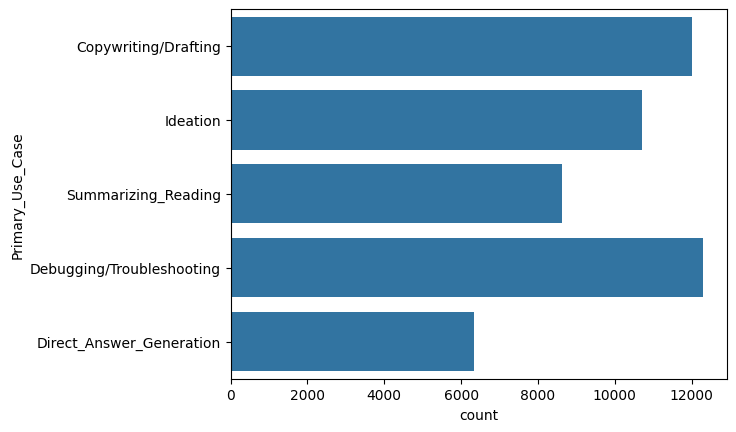

In [ ]:
sns.countplot(df["Primary_Use_Case"])

In [ ]:
df.isnull().sum()

,0
Student_ID,0
Major_Category,0
Year_of_Study,0
Pre_Semester_GPA,0
Weekly_GenAI_Hours,0
Primary_Use_Case,0
Prompt_Engineering_Skill,0
Tool_Diversity,0
Paid_Subscription,0
Traditional_Study_Hours,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  object 
 2   Year_of_Study               50000 non-null  object 
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  object 
 6   Prompt_Engineering_Skill    50000 non-null  object 
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  object 
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           500

In [ ]:
df.describe()

,Student_ID,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
count,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,125000.500000,3.146102,8.427752,2.80026,11.209271,3.505360,4.270760,3.349299,75.798125
std,14433.901067,0.478854,8.269490,1.18802,5.156426,1.820812,2.144066,0.495673,13.281626
min,100001.000000,1.183000,0.000000,1.00000,1.000000,1.000000,1.000000,1.000000,10.780000
25%,112500.750000,2.834000,2.390000,2.00000,7.560000,2.000000,3.000000,3.023750,66.820000
50%,125000.500000,3.210000,5.800000,3.00000,11.180000,3.000000,4.000000,3.421000,76.000000
75%,137500.250000,3.521000,11.720000,4.00000,14.710000,5.000000,6.000000,3.749000,85.190000
max,150000.000000,3.998000,40.000000,5.00000,35.860000,10.000000,10.000000,4.000000,100.000000


In [ ]:
from sklearn.pipeline import Pipeline

In [ ]:
df.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


In [ ]:
df[["Student_ID", "Weekly_GenAI_Hours"]].corr()

,Student_ID,Weekly_GenAI_Hours
Student_ID,1.000000,0.001577
Weekly_GenAI_Hours,0.001577,1.000000


In [ ]:
num_col=df.select_dtypes(include=["int64","float64"]).columns
num_col

Index(['Student_ID', 'Pre_Semester_GPA', 'Weekly_GenAI_Hours',
       'Tool_Diversity', 'Traditional_Study_Hours', 'Perceived_AI_Dependency',
       'Anxiety_Level_During_Exams', 'Post_Semester_GPA',
       'Skill_Retention_Score'],
      dtype='object')

In [ ]:
cat_col=df.select_dtypes(exclude=["int64","float64"]).columns
cat_col

Index(['Major_Category', 'Year_of_Study', 'Primary_Use_Case',
       'Prompt_Engineering_Skill', 'Paid_Subscription', 'Institutional_Policy',
       'Burnout_Risk_Level'],
      dtype='object')

In [ ]:
cat_col = list(cat_col)

cat_col.remove("Burnout_Risk_Level")

In [ ]:
cat_col

['Major_Category',
 'Year_of_Study',
 'Primary_Use_Case',
 'Prompt_Engineering_Skill',
 'Paid_Subscription',
 'Institutional_Policy']

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

In [ ]:
from sklearn.compose import ColumnTransformer

In [ ]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_col),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_col)
])

In [ ]:
X = df.drop("Burnout_Risk_Level", axis=1)

y = df["Burnout_Risk_Level"]

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y = le.fit_transform(y)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
X_train_processed = preprocessor.fit_transform(X_train)

In [ ]:
X_test_processed = preprocessor.transform(X_test)

In [ ]:
X_train_processed

array([[-1.62862727, -0.33383365,  0.68012857, ...,  0.        ,
         0.        ,  1.        ],
       [-1.4390311 , -0.03481067, -0.80547715, ...,  1.        ,
         0.        ,  0.        ],
       [ 0.9780429 ,  0.40013186, -0.2580218 , ...,  0.        ,
         0.        ,  1.        ],
       ...,
       [-0.06154839, -0.71231729,  1.38796181, ...,  1.        ,
         0.        ,  0.        ],
       [-0.27269588,  1.27838118, -0.93329713, ...,  1.        ,
         0.        ,  0.        ],
       [-0.95651716,  0.99190462,  0.03017606, ...,  0.        ,
         1.        ,  0.        ]])

In [ ]:
from sklearn.svm import SVC

In [ ]:
model = SVC()


In [ ]:
y_train

array([0, 2, 0, ..., 0, 2, 1])

In [ ]:
model.fit(
    X_train_processed,
    y_train
)

SVC()

In [ ]:
y_pred = model.predict(X_test_processed)

In [ ]:
y_pred = model.predict(X_test_processed)

In [ ]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred)

print(acc)

0.5264


In [ ]:
import pandas as pd

pd.Series(y_pred).value_counts()

,count
2,5803
1,2755
0,1442


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.70      0.40      0.51      2497
           1       0.54      0.45      0.49      3274
           2       0.48      0.66      0.55      4229

    accuracy                           0.53     10000
   macro avg       0.57      0.50      0.52     10000
weighted avg       0.55      0.53      0.52     10000



In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train_processed, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred_rf = rf.predict(X_test_processed)

In [ ]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred_rf)

print(acc)

0.5174
